In [1]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../analysisFunctions'))
sys.path.insert(0, dir1)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
import doubleml as dml
import pymc as pm
import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
import causalpy as cp
import pymc_bart as pmb

C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:84: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:94: FutureWarning: ndims_params is deprecated. Provide s

In [2]:
myPredictorsDf = pd.read_csv('../predictorsDf.csv')

In [32]:
myXValue = myPredictorsDf.drop(columns= ['CPC_SC3', 'CPC12', 'J0_SEX', 'SUBJID', 'BARTHEL_SC', 'SOFA_SC7', 'DS_DC', 'DAYS_ALIVE_30', 'J0_GLASGOW_CONTROLE', 'J0_CORDA_DOS'])
myFilter = myPredictorsDf['groupe'] != 2
myXValue = myXValue[myFilter]
myYValue = myPredictorsDf['CPC12']
X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[myFilter][['CPC12', 'groupe']], test_size=0.20)

In [33]:
myGridSearchCv = gridSearchKFoldRegression(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='r2')
myBestModel = myGridSearchCv.best_estimator_

Best parameters: {'clf': RandomForestRegressor(), 'clf__max_depth': None, 'clf__n_estimators': 200}
Best cross val r2 score: 0.0983
R2 score  on test set: 0.19316342592592617


In [34]:
myGridSearchCv = gridSearchKFoldClassification(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='roc_auc')
myBestModel = myGridSearchCv.best_estimator_

Best parameters: {'clf': SVC(kernel='linear', probability=True), 'clf__C': 0.1}
Best cross val roc_auc score: 0.8512
Area under the receiver operating curve on test set is 0.8488
Accuracy score on test set is 0.9231


c:\Program Files\miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Program Files\miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Program Files\miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


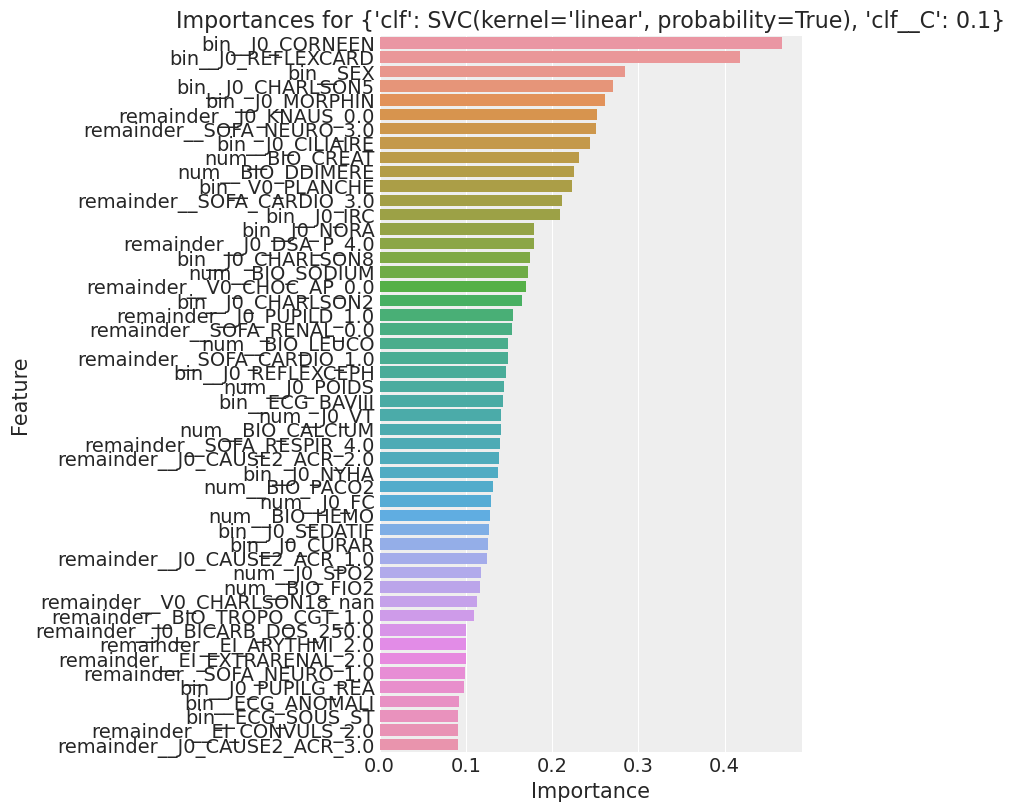

In [35]:
myFeatureImportancesDf = getTopFeatures(myGridSearchCv, list(myBestModel.named_steps['preprocessor'].get_feature_names_out()), X_train, y_train)

Optimization terminated successfully.
         Current function value: 0.249396
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.247170
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 1.6743715728926247
p-value: 0.43292716017022703
Degress of freedom: 2.0


c:\Program Files\miniconda3\lib\site-packages\patsy\util.py:672: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return _pandas_is_categorical_dtype(dt)
c:\Program Files\miniconda3\lib\site-packages\patsy\util.py:672: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return _pandas_is_categorical_dtype(dt)
c:\Program Files\miniconda3\lib\site-packages\patsy\util.py:672: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return _pandas_is_categorical_dtype(dt)
c:\Program Files\miniconda3\lib\site-packages\patsy\util.py:672: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return _pandas_is_catego

0.43292716017022703

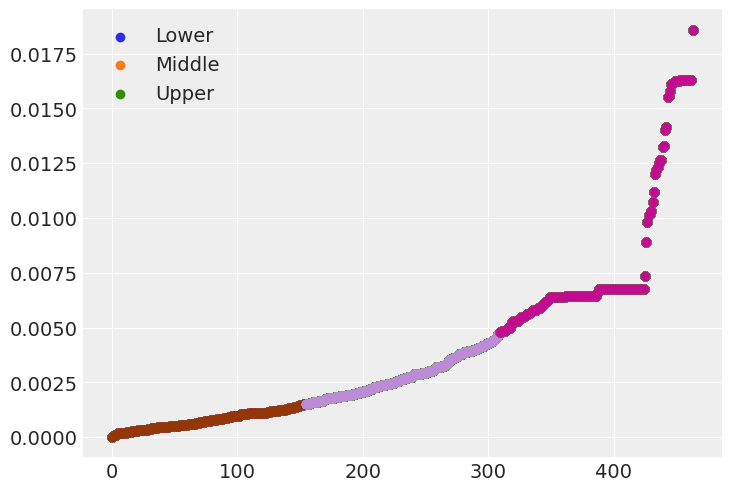

In [39]:
getTreatmentEffectDiff(X_train, y_train, myBestModel)